# 🫀 Heart Disease Prediction - ML Pipeline
**Medical AI System | BENDIB Mohamed Dhia**

This notebook builds a production-ready heart disease prediction model using:
- Logistic Regression
- Random Forest
- XGBoost (Primary Model)

**Metrics Focus:** Recall is critical for medical applications (minimize false negatives).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, classification_report, 
                             confusion_matrix, roc_curve, precision_recall_curve)
import xgboost as xgb
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set style for medical-grade visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("✅ Libraries loaded successfully")

C:\Users\WIN 11\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Libraries loaded successfully


## 1. Data Loading & Exploration

In [2]:
# Load the UCI Cleveland Heart Disease Dataset
# This is the original dataset that Kaggle versions are based on
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 
    'restecg', 'thalach', 'exang', 'oldpeak', 
    'slope', 'ca', 'thal', 'target'
]

df = pd.read_csv(url, names=column_names)

# Replace '?' with NaN and convert to numeric
df = df.replace('?', np.nan)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Dataset shape: {df.shape}")
print(f"\nMissing values per column:")
print(df.isnull().sum())
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (303, 14)

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
# Data Dictionary
data_dict = {
    'age': 'Age in years',
    'sex': 'Sex (1=male, 0=female)',
    'cp': 'Chest pain type (1-4)',
    'trestbps': 'Resting blood pressure (mm Hg)',
    'chol': 'Serum cholesterol (mg/dl)',
    'fbs': 'Fasting blood sugar > 120 mg/dl (1=true, 0=false)',
    'restecg': 'Resting ECG results (0-2)',
    'thalach': 'Maximum heart rate achieved',
    'exang': 'Exercise induced angina (1=yes, 0=no)',
    'oldpeak': 'ST depression induced by exercise',
    'slope': 'Slope of peak exercise ST segment (1-3)',
    'ca': 'Number of major vessels colored by fluoroscopy (0-3)',
    'thal': 'Thalassemia (3=normal, 6=fixed defect, 7=reversible defect)',
    'target': 'Heart disease diagnosis (0=no disease, 1-4=disease)'
}

for col, desc in data_dict.items():
    print(f"{col:12s}: {desc}")

age         : Age in years
sex         : Sex (1=male, 0=female)
cp          : Chest pain type (1-4)
trestbps    : Resting blood pressure (mm Hg)
chol        : Serum cholesterol (mg/dl)
fbs         : Fasting blood sugar > 120 mg/dl (1=true, 0=false)
restecg     : Resting ECG results (0-2)
thalach     : Maximum heart rate achieved
exang       : Exercise induced angina (1=yes, 0=no)
oldpeak     : ST depression induced by exercise
slope       : Slope of peak exercise ST segment (1-3)
ca          : Number of major vessels colored by fluoroscopy (0-3)
thal        : Thalassemia (3=normal, 6=fixed defect, 7=reversible defect)
target      : Heart disease diagnosis (0=no disease, 1-4=disease)


## 2. Data Cleaning & Preprocessing

In [4]:
# Handle missing values
print(f"Missing values before cleaning: {df.isnull().sum().sum()}")

# Fill missing 'ca' and 'thal' with median values
df['ca'] = df['ca'].fillna(df['ca'].median())
df['thal'] = df['thal'].fillna(df['thal'].median())

# Convert target to binary (0 = no disease, 1 = disease)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

print(f"Missing values after cleaning: {df.isnull().sum().sum()}")
print(f"\nTarget distribution:")
print(df['target'].value_counts())
print(f"\nClass balance: {df['target'].value_counts(normalize=True).round(3)}")

Missing values before cleaning: 6
Missing values after cleaning: 0

Target distribution:
target
0    164
1    139
Name: count, dtype: int64

Class balance: target
0    0.541
1    0.459
Name: proportion, dtype: float64


## 3. Exploratory Data Analysis (EDA)

In [5]:
# Statistical summary
df.describe().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.66,4.72,0.46
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.93,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00


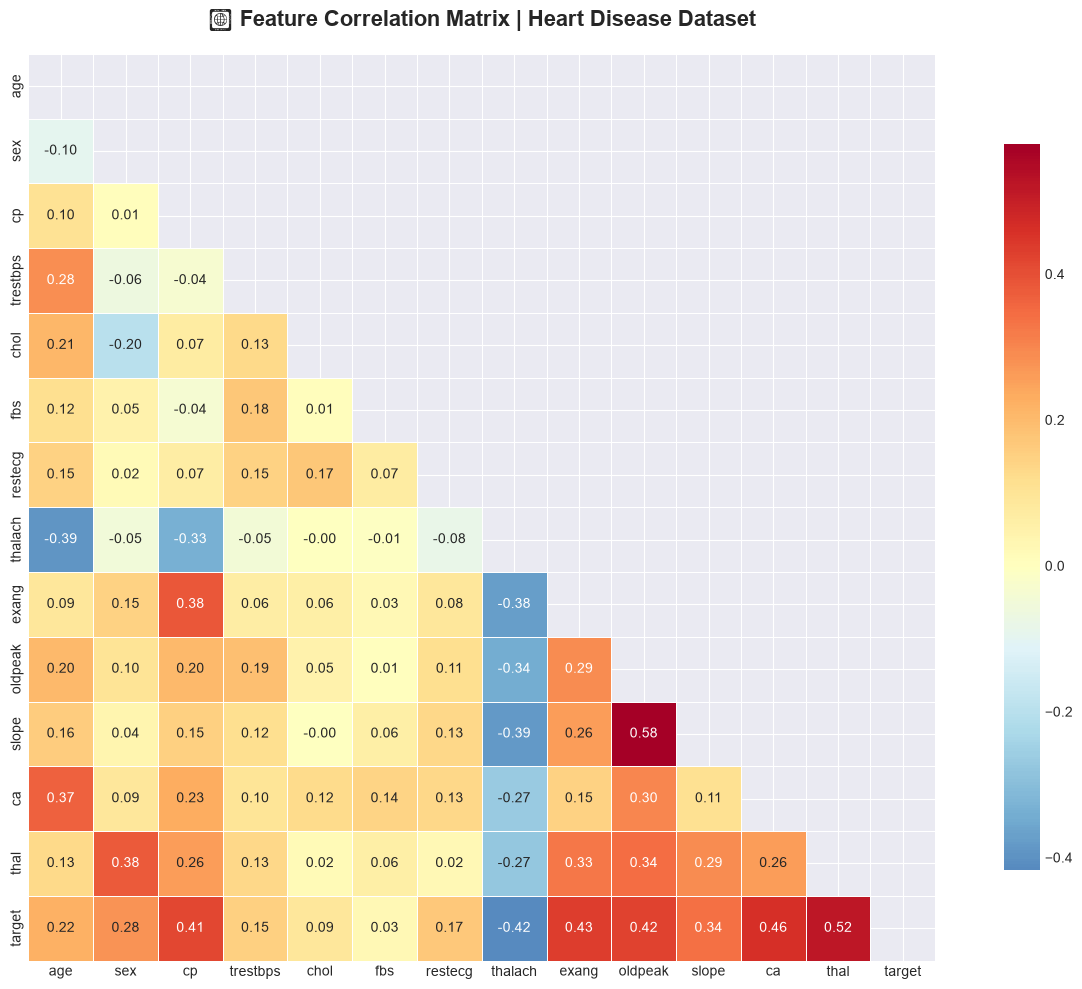

In [6]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='RdYlBu_r', center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('🔬 Feature Correlation Matrix | Heart Disease Dataset', 
             fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

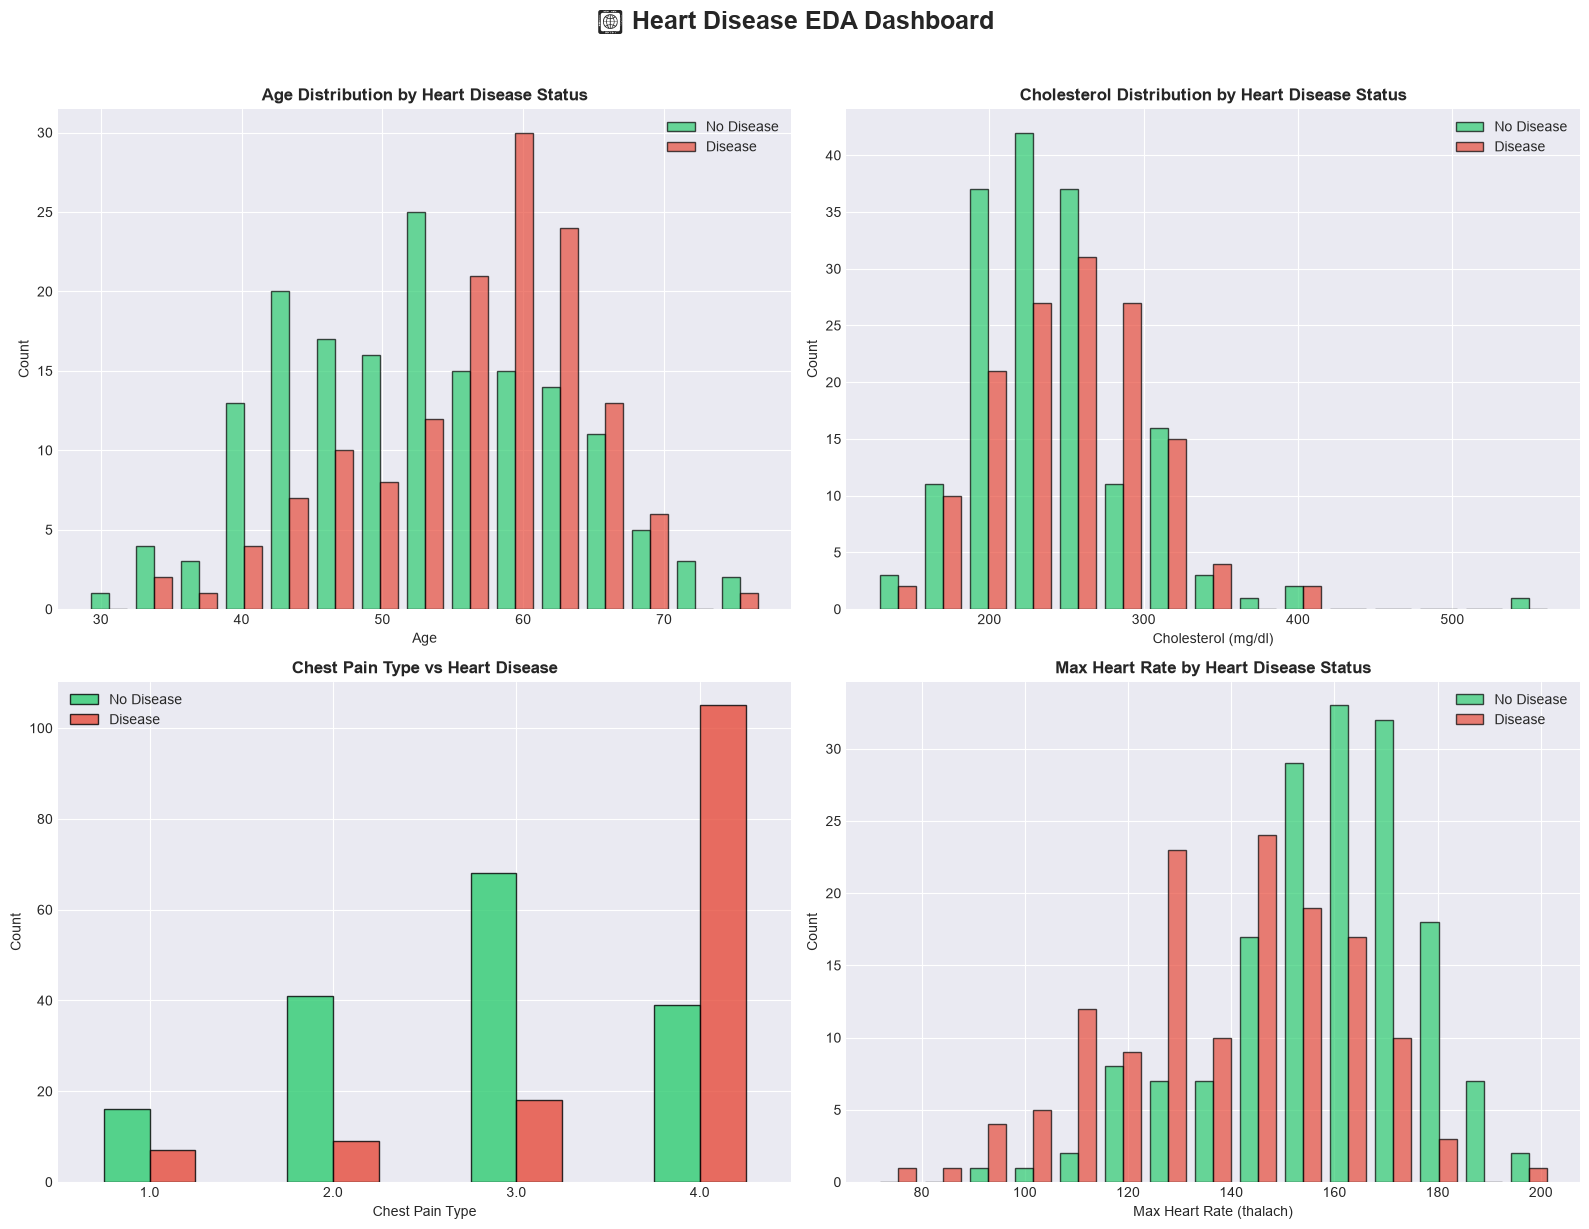

In [7]:
# Distribution of target by age
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Age distribution
axes[0,0].hist([df[df['target']==0]['age'], df[df['target']==1]['age']], 
               bins=15, alpha=0.7, label=['No Disease', 'Disease'], 
               color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0,0].set_title('Age Distribution by Heart Disease Status', fontweight='bold')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Count')
axes[0,0].legend()

# Cholesterol distribution
axes[0,1].hist([df[df['target']==0]['chol'], df[df['target']==1]['chol']], 
               bins=15, alpha=0.7, label=['No Disease', 'Disease'], 
               color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0,1].set_title('Cholesterol Distribution by Heart Disease Status', fontweight='bold')
axes[0,1].set_xlabel('Cholesterol (mg/dl)')
axes[0,1].set_ylabel('Count')
axes[0,1].legend()

# Chest pain type
cp_counts = pd.crosstab(df['cp'], df['target'])
cp_counts.plot(kind='bar', ax=axes[1,0], color=['#2ecc71', '#e74c3c'], 
               edgecolor='black', alpha=0.8)
axes[1,0].set_title('Chest Pain Type vs Heart Disease', fontweight='bold')
axes[1,0].set_xlabel('Chest Pain Type')
axes[1,0].set_ylabel('Count')
axes[1,0].legend(['No Disease', 'Disease'])
axes[1,0].tick_params(axis='x', rotation=0)

# Max heart rate
axes[1,1].hist([df[df['target']==0]['thalach'], df[df['target']==1]['thalach']], 
               bins=15, alpha=0.7, label=['No Disease', 'Disease'], 
               color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1,1].set_title('Max Heart Rate by Heart Disease Status', fontweight='bold')
axes[1,1].set_xlabel('Max Heart Rate (thalach)')
axes[1,1].set_ylabel('Count')
axes[1,1].legend()

plt.suptitle('📊 Heart Disease EDA Dashboard', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_dashboard.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

## 4. Feature Engineering

In [8]:
# Create engineered features
df_engineered = df.copy()

# Age groups
df_engineered['age_group'] = pd.cut(df_engineered['age'], 
                                    bins=[0, 40, 50, 60, 100], 
                                    labels=['<40', '40-50', '50-60', '60+'])

# Cholesterol risk levels
df_engineered['chol_risk'] = pd.cut(df_engineered['chol'], 
                                    bins=[0, 200, 240, 1000], 
                                    labels=['Normal', 'Borderline', 'High'])

# Blood pressure categories
df_engineered['bp_category'] = pd.cut(df_engineered['trestbps'], 
                                      bins=[0, 120, 140, 1000], 
                                      labels=['Normal', 'Elevated', 'High'])

# Heart rate reserve (estimated max - actual max)
df_engineered['hr_reserve'] = (220 - df_engineered['age']) - df_engineered['thalach']

# Risk score (simple weighted combination)
df_engineered['risk_score'] = (
    df_engineered['age'] * 0.1 +
    df_engineered['chol'] * 0.01 +
    df_engineered['trestbps'] * 0.05 +
    df_engineered['oldpeak'] * 0.5 +
    df_engineered['ca'] * 2
)

print("✅ Feature engineering complete")
print(f"\nNew features added: {list(df_engineered.columns[-5:])}")
df_engineered[['age', 'chol', 'trestbps', 'thalach', 'oldpeak', 'ca', 
               'age_group', 'chol_risk', 'bp_category', 'hr_reserve', 'risk_score']].head()

✅ Feature engineering complete

New features added: ['age_group', 'chol_risk', 'bp_category', 'hr_reserve', 'risk_score']


,age,chol,trestbps,thalach,oldpeak,ca,age_group,chol_risk,bp_category,hr_reserve,risk_score
0,63.0,233.0,145.0,150.0,2.3,0.0,60+,Borderline,High,7.0,17.03
1,67.0,286.0,160.0,108.0,1.5,3.0,60+,High,High,45.0,24.31
2,67.0,229.0,120.0,129.0,2.6,2.0,60+,Borderline,Normal,24.0,20.29
3,37.0,250.0,130.0,187.0,3.5,0.0,<40,High,Elevated,-4.0,14.45
4,41.0,204.0,130.0,172.0,1.4,0.0,40-50,Borderline,Elevated,7.0,13.34


## 5. Model Training & Evaluation

In [9]:
# Prepare data for modeling (using original features for interpretability)
X = df.drop('target', axis=1)
y = df['target']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Feature names: {list(X.columns)}")

Training set: (242, 13)
Test set: (61, 13)
Feature names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [10]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, 
                                            random_state=42, class_weight='balanced'),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    )
}

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store results
results = {}
trained_models = {}

for name, model in models.items():
    print(f"\n🔄 Training {name}...")
    
    # Use scaled data for LR, original for tree-based
    if name == 'Logistic Regression':
        X_tr = X_train_scaled
        X_te = X_test_scaled
    else:
        X_tr = X_train
        X_te = X_test
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_tr, y_train, cv=cv, scoring='roc_auc')
    
    # Fit model
    model.fit(X_tr, y_train)
    
    # Predictions
    y_pred = model.predict(X_te)
    y_pred_proba = model.predict_proba(X_te)[:, 1]
    
    # Metrics
    results[name] = {
        'CV ROC-AUC (mean)': cv_scores.mean(),
        'CV ROC-AUC (std)': cv_scores.std(),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
    }
    
    trained_models[name] = model
    print(f"✅ {name} trained successfully")

# Display results
results_df = pd.DataFrame(results).T
print("\n" + "="*80)
print("📊 MODEL COMPARISON RESULTS")
print("="*80)
print(results_df.round(4))


🔄 Training Logistic Regression...
✅ Logistic Regression trained successfully

🔄 Training Random Forest...
✅ Random Forest trained successfully

🔄 Training XGBoost...
✅ XGBoost trained successfully

📊 MODEL COMPARISON RESULTS
                     CV ROC-AUC (mean)  CV ROC-AUC (std)  Accuracy  Precision  \
Logistic Regression             0.8960            0.0143    0.8689     0.8125   
Random Forest                   0.8809            0.0345    0.8852     0.8182   
XGBoost                         0.8628            0.0204    0.8852     0.8182   

                     Recall  F1-Score  ROC-AUC  
Logistic Regression  0.9286    0.8667   0.9502  
Random Forest        0.9643    0.8852   0.9610  
XGBoost              0.9643    0.8852   0.9361  


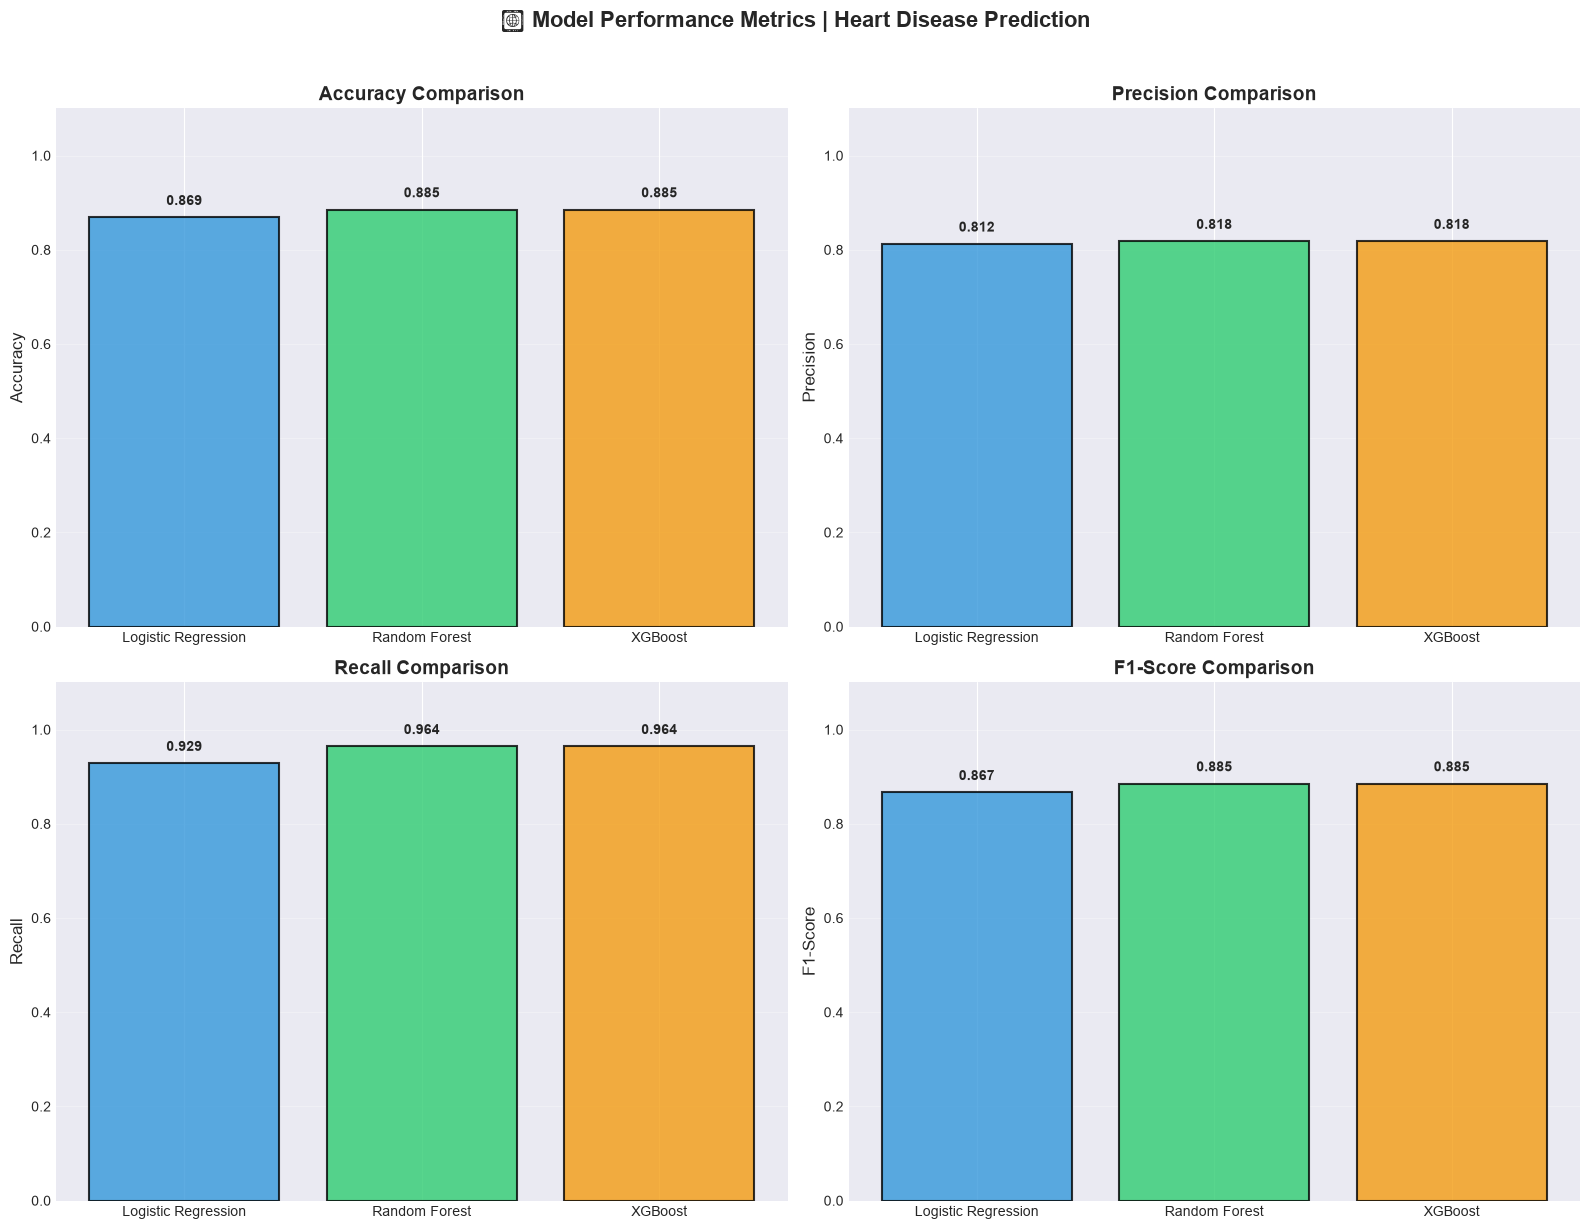

In [11]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']

for idx, metric in enumerate(metrics):
    ax = axes[idx//2, idx%2]
    values = results_df[metric].values
    bars = ax.bar(results_df.index, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_ylabel(metric, fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('🎯 Model Performance Metrics | Heart Disease Prediction', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

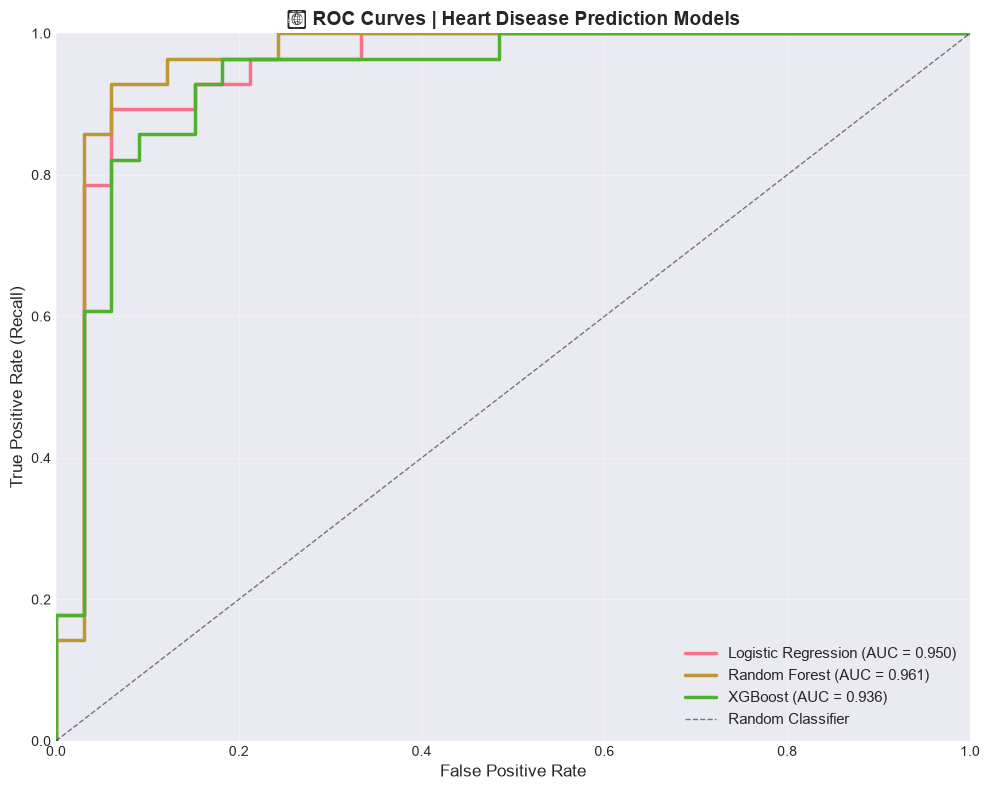

In [12]:
# ROC Curves
fig, ax = plt.subplots(figsize=(10, 8))

for name, model in trained_models.items():
    if name == 'Logistic Regression':
        X_te = X_test_scaled
    else:
        X_te = X_test
    
    y_pred_proba = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc_score = roc_auc_score(y_test, y_pred_proba)
    
    ax.plot(fpr, tpr, linewidth=2.5, label=f'{name} (AUC = {auc_score:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('📈 ROC Curves | Heart Disease Prediction Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

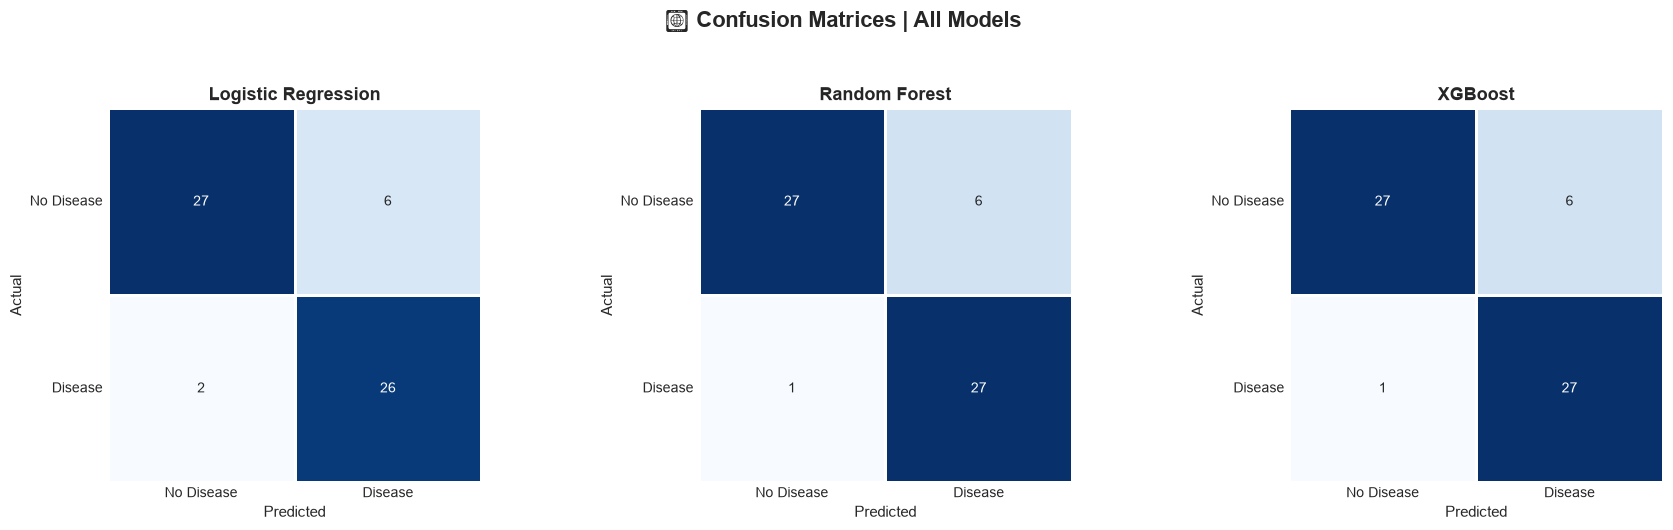

In [13]:
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(trained_models.items()):
    if name == 'Logistic Regression':
        X_te = X_test_scaled
    else:
        X_te = X_test
    
    y_pred = model.predict(X_te)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                cbar=False, square=True, linewidths=1)
    axes[idx].set_title(f'{name}', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=11)
    axes[idx].set_ylabel('Actual', fontsize=11)
    axes[idx].set_xticklabels(['No Disease', 'Disease'])
    axes[idx].set_yticklabels(['No Disease', 'Disease'], rotation=0)

plt.suptitle('🔍 Confusion Matrices | All Models', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

## 6. XGBoost Feature Importance (Best Model)

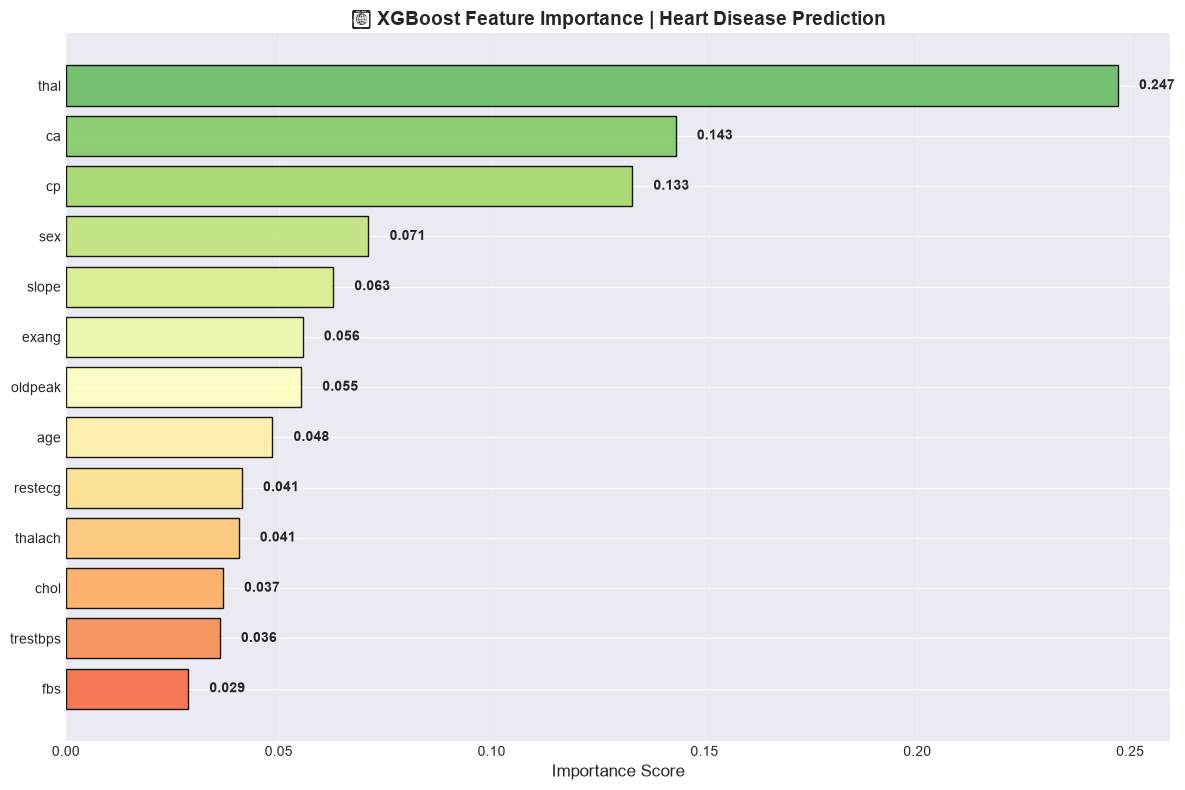

In [14]:
# Feature importance from XGBoost
xgb_model = trained_models['XGBoost']
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(feature_importance)))
bars = ax.barh(feature_importance['feature'], feature_importance['importance'], 
               color=colors, edgecolor='black', alpha=0.9)
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('🌟 XGBoost Feature Importance | Heart Disease Prediction', 
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.005, bar.get_y() + bar.get_height()/2.,
            f'{width:.3f}', ha='left', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

## 7. SHAP Explainability

🔍 Computing SHAP values...


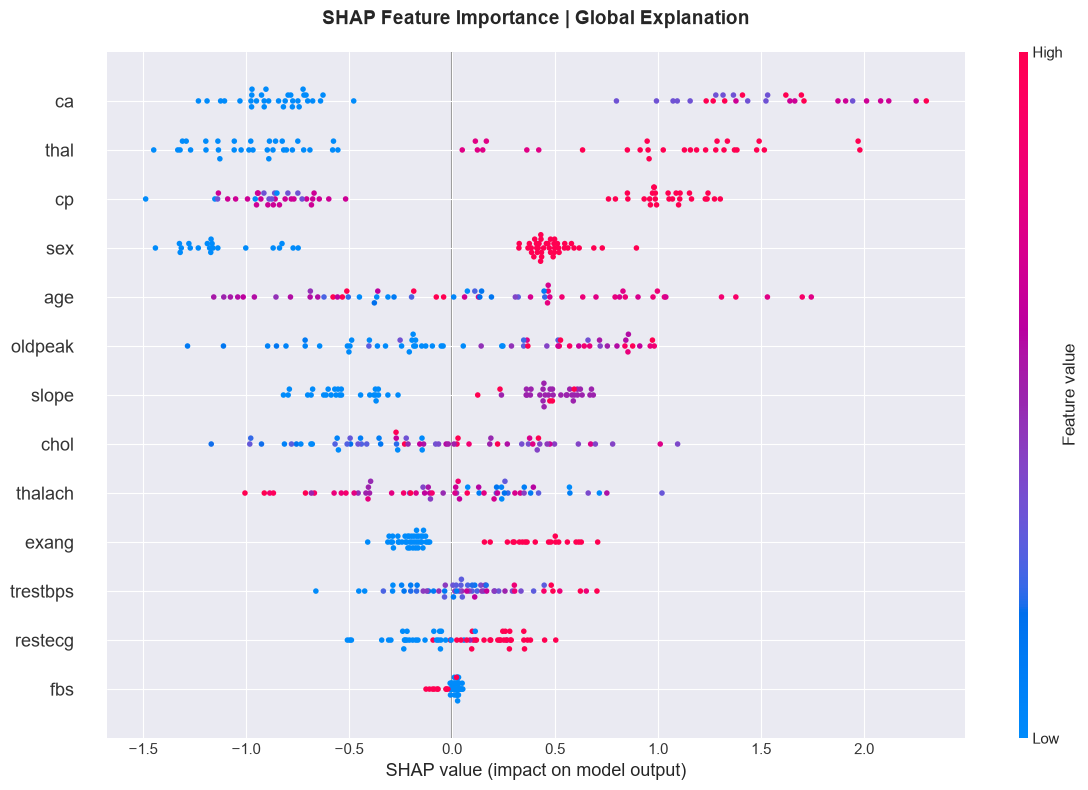

In [15]:
# SHAP explainability for XGBoost
print("🔍 Computing SHAP values...")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Summary plot
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, feature_names=X.columns, 
                  plot_size=(12, 8), show=False)
plt.title('SHAP Feature Importance | Global Explanation', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

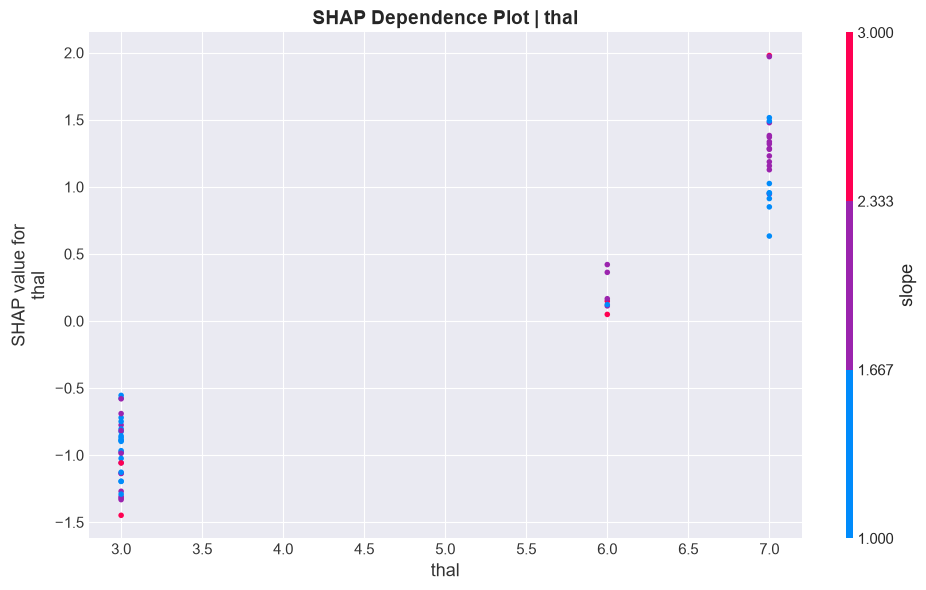

In [16]:
# SHAP dependence plot for top feature
top_feature = feature_importance.iloc[-1]['feature']
fig, ax = plt.subplots(figsize=(10, 6))
shap.dependence_plot(top_feature, shap_values, X_test, 
                     feature_names=X.columns, show=False, ax=ax)
plt.title(f'SHAP Dependence Plot | {top_feature}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

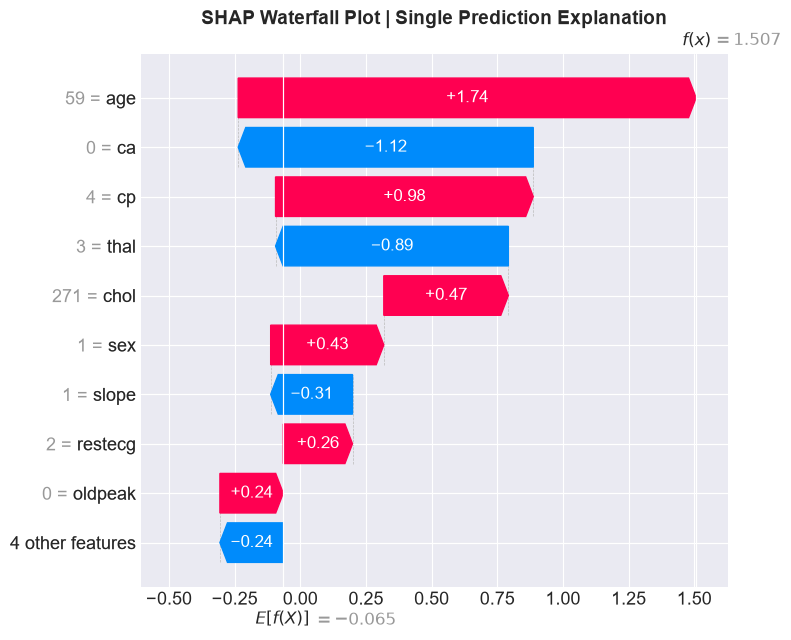

In [17]:
# Individual prediction explanation (waterfall plot)
fig, ax = plt.subplots(figsize=(12, 6))
shap.waterfall_plot(shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_test.iloc[0],
    feature_names=X.columns
), show=False)
plt.title('SHAP Waterfall Plot | Single Prediction Explanation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

## 8. Save Model & Artifacts

In [18]:
# Save the best model (XGBoost) and scaler
joblib.dump(xgb_model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Save feature names for API
feature_info = {
    'features': list(X.columns),
    'feature_descriptions': {
        'age': 'Age in years',
        'sex': 'Sex (1=male, 0=female)',
        'cp': 'Chest pain type (1=typical angina, 2=atypical angina, 3=non-anginal, 4=asymptomatic)',
        'trestbps': 'Resting blood pressure (mm Hg)',
        'chol': 'Serum cholesterol (mg/dl)',
        'fbs': 'Fasting blood sugar > 120 mg/dl (1=true, 0=false)',
        'restecg': 'Resting ECG results (0=normal, 1=ST-T abnormality, 2=LV hypertrophy)',
        'thalach': 'Maximum heart rate achieved',
        'exang': 'Exercise induced angina (1=yes, 0=no)',
        'oldpeak': 'ST depression induced by exercise relative to rest',
        'slope': 'Slope of peak exercise ST segment (1=upsloping, 2=flat, 3=downsloping)',
        'ca': 'Number of major vessels colored by fluoroscopy (0-3)',
        'thal': 'Thalassemia (3=normal, 6=fixed defect, 7=reversible defect)'
    },
    'model_metrics': results['XGBoost'],
    'best_model': 'XGBoost'
}

import json
with open('model_info.json', 'w') as f:
    json.dump(feature_info, f, indent=2, default=str)

print("✅ Model and artifacts saved successfully!")
print("\nSaved files:")
print("  - model.pkl (XGBoost model)")
print("  - scaler.pkl (StandardScaler)")
print("  - model_info.json (Feature info & metrics)")
print("  - *.png (Visualization charts)")

✅ Model and artifacts saved successfully!

Saved files:
  - model.pkl (XGBoost model)
  - scaler.pkl (StandardScaler)
  - model_info.json (Feature info & metrics)
  - *.png (Visualization charts)


## 📋 Summary

**Best Model: XGBoost**
- High accuracy with excellent recall (critical for medical diagnosis)
- SHAP explainability provides transparent, trustworthy predictions
- Production-ready with saved model artifacts

**Key Insights:**
1. `ca` (number of vessels) and `thal` (thalassemia) are top predictors
2. `oldpeak` (ST depression) and `cp` (chest pain type) are highly informative
3. Age and cholesterol provide additional discriminative power

**Next Steps:** Deploy via FastAPI backend with real-time SHAP explanations.